# Exploratory Data Analysis (EDA) – Annual Sales Dataset

## Project Objectives

The main objective of this analysis is to explore the complete annual sales dataset and identify meaningful business insights by examining sales performance, product trends, customer purchasing behavior, delivery platform performance, and seasonal patterns throughout the year. In addition, the analysis aims to compare the four quarters to evaluate business growth, identify the best-performing periods, and support data-driven decision-making.

Specifically, this analysis aims to:

- Evaluate the overall sales performance for the entire year.
- Summarize the main business KPIs, including revenue, orders, quantity sold, and average order value.
- Identify the best-selling and lowest-selling products.
- Analyze returned products and their impact on sales.
- Examine monthly, weekly, and hourly sales patterns throughout the year.
- Analyze the performance of delivery platforms based on revenue and completed orders.
- Compare sales performance across the four quarters.
- Measure revenue growth between consecutive quarters.
- Identify the best-performing quarter of the year.
- Discover trends and business insights that can support future operational and marketing decisions.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load and Merge Quarterly Datasets

This section loads the cleaned datasets for each quarter, assigns a quarter label to each dataset, merges them into a single annual dataset, and sorts the records chronologically. The resulting dataset serves as the foundation for the annual exploratory data analysis and quarterly performance comparison.

### 2.1 Load Quarterly Datasets

In [2]:
# Load the cleaned quarterly datasets
df_q1 = pd.read_excel("../../../Data/Cleaned/clean_q1_data.xlsx")
df_q2 = pd.read_excel("../../../Data/Cleaned/clean_q2_data.xlsx")
df_q3 = pd.read_excel("../../../Data/Cleaned/clean_q3_data.xlsx")
df_q4 = pd.read_excel("../../../Data/Cleaned/clean_q4_data.xlsx")

### 2.2 Assign Quarter Labels

In [3]:
# Add quarter labels
df_q1["Quarter"] = "Q1"
df_q2["Quarter"] = "Q2"
df_q3["Quarter"] = "Q3"
df_q4["Quarter"] = "Q4"

### 2.3 Merge and Sort the Dataset

In [4]:
# Merge all quarters into one dataset
df = pd.concat(
    [df_q1, df_q2, df_q3, df_q4],
    ignore_index=True
)

# Define quarter order
quarter_order = ["Q1", "Q2", "Q3", "Q4"]

df["Quarter"] = pd.Categorical(
    df["Quarter"],
    categories=quarter_order,
    ordered=True
)

# Sort by quarter and date
df = df.sort_values(
    by=["Quarter", "Date"]
).reset_index(drop=True)

# Create a working copy
df1 = df.copy()

### 2.2 Verify the Merged Dataset

In [5]:
print(f"Q1 Records : {len(df_q1):,}")
print(f"Q2 Records : {len(df_q2):,}")
print(f"Q3 Records : {len(df_q3):,}")
print(f"Q4 Records : {len(df_q4):,}")
print(f"= {len(df_q1) + len(df_q2) + len(df_q3) + len(df_q4) }")
print("-" * 35)

print(f"Annual Records : {len(df1):,}")

Q1 Records : 41,840
Q2 Records : 45,143
Q3 Records : 42,788
Q4 Records : 53,897
= 183668
-----------------------------------
Annual Records : 183,668


## 3. Dataset Overview

This section provides a general overview of the merged annual dataset by examining its structure, data types, missing values, duplicate records, and descriptive statistics before performing the exploratory data analysis.

### 3.1 Dataset Shape

In [6]:
print(f"Total Records : {len(df1):,}")
print(f"Total Columns : {df1.shape[1]}")

Total Records : 183,668
Total Columns : 9


### 3.2 Data Types

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183668 entries, 0 to 183667
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date            183668 non-null  datetime64[ns]
 1   Receipt Number  183668 non-null  object        
 2   Customer        57863 non-null   object        
 3   Product         183668 non-null  object        
 4   Quantity        183668 non-null  float64       
 5   Unit_Price      183668 non-null  float64       
 6   Subtotal        183668 non-null  float64       
 7   Total           66978 non-null   float64       
 8   Quarter         183668 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(4), object(3)
memory usage: 11.4+ MB


### 3.3 Descriptive Statistics

In [8]:
df1.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,183668,NaN,NaN,NaN,2025-07-08 19:52:59.355369472,2025-01-01 06:09:10,2025-04-09 08:27:51.249999872,2025-07-15 22:18:01,2025-10-14 07:18:14,2025-12-31 23:45:59,NaN
Receipt Number,183668,66973,طلب 05163-003-0725,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer,57863,1721,ابوتركى,14730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,183668,215,ماء,8164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,183668.0,NaN,NaN,NaN,1.563223,-446.0,1.0,1.0,2.0,650.0,3.809607
Unit_Price,183668.0,NaN,NaN,NaN,11.227811,-20.1,4.0,6.0,13.0,220.0,13.230574
Subtotal,183668.0,NaN,NaN,NaN,14.728771,-2676.0,4.0,10.0,20.0,3900.0,26.021266
Total,66978.0,NaN,NaN,NaN,40.408173,-2696.0,11.0,25.0,54.0,3900.0,54.958563
Quarter,183668,4,Q4,53897,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.4 Missing Values Check

In [9]:
df1.isna().sum()

Date                   0
Receipt Number         0
Customer          125805
Product                0
Quantity               0
Unit_Price             0
Subtotal               0
Total             116690
Quarter                0
dtype: int64

> **Note:** The missing values in the **Customer** and **Total** columns are expected and do not indicate data quality issues. Customer information is only recorded for transactions associated with registered customers or delivery applications, while many in-store transactions do not contain customer names. Similarly, the **Total** value represents the overall amount of an entire receipt and is intentionally stored only once for each transaction rather than being repeated for every product line. Therefore, these missing values were retained as they accurately reflect the original transaction structure.

### 3.5 Duplicate Records Check

In [10]:
df1.duplicated().sum()

np.int64(0)

### 3.6 Date Range

In [11]:
print(df1["Date"].min())
print(df1["Date"].max())

2025-01-01 06:09:10
2025-12-31 23:45:59


### 3.7 Business Summary

In [12]:
print(f"Total Records : {len(df1):,}")
print(f"Unique Orders : {df1['Receipt Number'].nunique():,}")
print(f"Unique Products : {df1['Product'].nunique():,}")
print(f"Unique Customers : {df1['Customer'].nunique():,}")

Total Records : 183,668
Unique Orders : 66,973
Unique Products : 215
Unique Customers : 1,721


## 4. Annual Sales Performance

This section summarizes the overall sales performance for the entire year by presenting the main business key performance indicators (KPIs).

In [13]:
total_revenue = df1["Subtotal"].sum()
total_quantity = df1["Quantity"].sum()
total_orders = df1["Receipt Number"].nunique()

average_order_value = total_revenue / total_orders
average_selling_price = df1["Unit_Price"].mean()
average_items_per_order = total_quantity / total_orders

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,.0f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: {average_order_value:.2f}")
print(f"Average Selling Price: {average_selling_price:.2f}")
print(f"Average Items per Order: {average_items_per_order:.2f}")

Total Revenue: 2,705,203.98
Total Quantity Sold: 287,114
Total Orders: 66,973
Average Order Value: 40.39
Average Selling Price: 11.23
Average Items per Order: 4.29


## 5. Annual Product Analysis

This section evaluates product performance across the entire year by identifying the highest- and lowest-performing products based on revenue and sales quantity. It also examines returned products and summarizes key product performance metrics.

### 5.1 Top Products by Revenue

Identify the products that generated the highest revenue.

In [14]:
top_revenue_products = (
    df1.groupby("Product")["Subtotal"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

top_revenue_products

Product
صحن تكا روب          132918.60
سيخ تكا روب          132302.60
صحن سبشل تكا          95472.36
صحن 21 سيخ مشكل       89002.00
صحن تكا ليمون         86327.80
هريس لحم صغير         83789.10
باجا كوارع            79525.71
صاروخ تكا لحم روب     75709.24
حمص                   70653.40
سندويش كبدة           60731.32
Name: Subtotal, dtype: float64

### 5.2 Top Products by Quantity Sold

Identify the products with the highest sales volume.

In [15]:
top_quantity_products = (
    df1.groupby("Product")["Quantity"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

top_quantity_products

Product
سيخ تكا روب          26101.0
ماء                  12850.2
خبز عربي تنور        11736.0
كينزا كولا           11130.0
سندويش بيض بالجبن    10641.0
سيخ تكا ليمون        10202.0
سندويش كبدة          10120.0
سيخ تكا دجاج          8610.0
هريس لحم صغير         8544.0
صحن بطاطس             7268.0
Name: Quantity, dtype: float64

### 5.4 Lowest-Selling Products

Identify the products with the lowest sales volume.

In [16]:
lowest_quantity_products = (
    df1.groupby("Product")["Quantity"]
       .sum()
       .sort_values()
       .head(10)
)

lowest_quantity_products

Product
حبة دجاج على الفحم رز برياني    1.0
عصير برتقال                     1.0
كبة جبن                         1.0
نصف دجاج على الفحم رز غوزي      1.0
حبة دجاج على الفحم رز غوزي      2.0
كريم كراميل                     2.0
سلطة زيتون (نسخة)               2.0
سندويش حلوم                     2.0
حبة دجاج على الفحم رز مندي      2.0
صحن رمضاني مشكل صغير            2.0
Name: Quantity, dtype: float64

### 5.5 Most Returned Products

Identify the products with the highest number of returned items based on negative sales quantities.


In [17]:
returned_products = (
    df1[df1["Quantity"] < 0]
    .groupby("Product")["Quantity"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

returned_products

Product
صاروخ تكا لحم روب (نسخة)    450.0
ربع دجاجة على الفحم         126.0
كينزا كولا                  117.0
ماء                         111.0
خبز عربي تنور                85.0
خبز بالجبن                   84.0
سندويش بيض بالجبن            55.0
سيخ تكا روب                  49.0
سندويش كبدة                  47.0
صحن بطاطس                    36.0
Name: Quantity, dtype: float64

## 6. Quarterly Performance Comparison

This section compares the sales performance across the four quarters of the year. It highlights differences in revenue, order volume, sales quantity, and average order value to identify the strongest and weakest performing quarters.

### 6.1 Revenue by Quarter

In [18]:
quarter_revenue = (
    df1.groupby("Quarter", observed=False)["Subtotal"]
       .sum()
       .reset_index(name="Revenue")
)

quarter_revenue

,Quarter,Revenue
0,Q1,610056.57
1,Q2,648572.98
2,Q3,625920.63
3,Q4,820653.80


### 6.2 Orders by Quarter

In [19]:
quarter_orders = (
    df1.groupby("Quarter", observed=False)["Receipt Number"]
       .nunique()
       .reset_index(name="Orders")
)

quarter_orders

,Quarter,Orders
0,Q1,15406
1,Q2,15333
2,Q3,15415
3,Q4,20819


### 6.3 Quantity Sold by Quarter

In [20]:
quarter_quantity = (
    df1.groupby("Quarter", observed=False)["Quantity"]
       .sum()
       .reset_index(name="Quantity Sold")
)

quarter_quantity

,Quarter,Quantity Sold
0,Q1,69514.5
1,Q2,70649.2
2,Q3,66759.8
3,Q4,80190.5


### 6.4 Average Order Value by Quarter

In [21]:
quarter_aov = (
    df1.groupby("Quarter", observed=False)
       .agg(
           Revenue=("Subtotal", "sum"),
           Orders=("Receipt Number", "nunique")
       )
)

quarter_aov["Average Order Value"] = (
    quarter_aov["Revenue"] / quarter_aov["Orders"]
)

quarter_aov = (
    quarter_aov[["Average Order Value"]]
    .reset_index()
)

quarter_aov

,Quarter,Average Order Value
0,Q1,39.598635
1,Q2,42.299157
2,Q3,40.604647
3,Q4,39.418502


### 6.5 Quarter-over-Quarter Revenue Growth

In [22]:
quarter_growth = quarter_revenue.copy()

quarter_growth["Growth (%)"] = (
    quarter_growth["Revenue"]
    .pct_change()
    .mul(100)
    .round(2)
)

quarter_growth

,Quarter,Revenue,Growth (%)
0,Q1,610056.57,NaN
1,Q2,648572.98,6.31
2,Q3,625920.63,-3.49
3,Q4,820653.80,31.11


> **Observation:**  
> The quarterly revenue trend shows steady growth from **Q1** to **Q2** (+6.31%), followed by a slight decline in **Q3** (-3.49%). Sales performance recovered strongly in **Q4**, achieving a **31.11%** increase over Q3. This indicates that the final quarter contributed the most significant improvement in annual revenue and was the strongest-performing quarter.

## 7. Annual Time-Based Sales Analysis

This section analyzes sales performance across different time dimensions, including months, weekdays, and hours. The objective is to identify seasonal patterns, peak business periods, and customer purchasing behavior throughout the year.

### Date Feature Engineering

In [23]:
# Extract useful date and time features.
df1["Month"] = df1["Date"].dt.month_name()
df1["Month_Number"] = df1["Date"].dt.month
df1["Weekday"] = df1["Date"].dt.day_name()
df1["Hour"] = df1["Date"].dt.hour

### 7.1 Monthly Revenue

In [24]:
monthly_revenue = (
    df1.groupby(["Month_Number", "Month"], observed=False)["Subtotal"]
       .sum()
       .reset_index()
)

monthly_revenue

,Month_Number,Month,Subtotal
0,1,January,257025.21
1,2,February,232426.66
2,3,March,120604.70
3,4,April,216684.10
4,5,May,234395.82
5,6,June,197493.06
6,7,July,172211.16
7,8,August,205639.40
8,9,September,248070.07
9,10,October,293919.48


### 7.2 Monthly Orders

In [25]:
monthly_orders = (
    df1.groupby(["Month_Number", "Month"], observed=False)["Receipt Number"]
       .nunique()
       .reset_index(name="Orders")
)

monthly_orders

,Month_Number,Month,Orders
0,1,January,6338
1,2,February,5886
2,3,March,3182
3,4,April,5299
4,5,May,5639
5,6,June,4395
6,7,July,4197
7,8,August,4983
8,9,September,6235
9,10,October,7428


### 7.3 Revenue by Weekday

In [26]:
weekday_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

weekday_revenue = (
    df1.groupby("Weekday", observed=False)["Subtotal"]
       .sum()
       .reindex(weekday_order)
)

weekday_revenue

Weekday
Sunday       316095.18
Monday       359857.78
Tuesday      357681.29
Wednesday    392596.51
Thursday     458732.52
Friday       441249.64
Saturday     378991.06
Name: Subtotal, dtype: float64

### 7.4 Orders by Weekday

In [27]:
weekday_orders = (
    df1.groupby("Weekday", observed=False)["Receipt Number"]
       .nunique()
       .reindex(weekday_order)
)

weekday_orders

Weekday
Sunday        9183
Monday        9782
Tuesday       9828
Wednesday    10449
Thursday     10749
Friday        8476
Saturday      8506
Name: Receipt Number, dtype: int64

### 7.5 Revenue by Hour

In [28]:
hourly_revenue = (
    df1.groupby("Hour")["Subtotal"]
       .sum()
       .sort_index()
)

hourly_revenue

Hour
0      47752.08
1      32802.46
2      28579.90
3       6076.56
4       1420.60
5       1051.00
6      74252.23
7     136429.60
8     124033.26
9     117604.00
10     87007.41
11     22449.85
12     43235.00
13     56920.60
14     42645.10
15     35122.80
16     44024.70
17     33349.80
18     96041.84
19    227731.08
20    344885.34
21    412823.73
22    392437.62
23    296527.42
Name: Subtotal, dtype: float64

### 7.6 Orders by Hour

In [29]:
hourly_orders = (
    df1.groupby("Hour")["Receipt Number"]
       .nunique()
       .sort_index()
)

hourly_orders

Hour
0      719
1      676
2      473
3       92
4       34
5       51
6     4536
7     7618
8     6025
9     5220
10    3868
11    1081
12    1153
13    1443
14    1211
15    1137
16    1440
17    1169
18    2142
19    4161
20    5665
21    6449
22    5982
23    4637
Name: Receipt Number, dtype: int64

### 7.7 Peak Sales Summary

In [30]:
print("Peak Sales Month   :", monthly_revenue.loc[monthly_revenue["Subtotal"].idxmax(), "Month"])
print("Peak Sales Weekday :", weekday_revenue.idxmax())
print(f"Peak Sales Hour    : {hourly_revenue.idxmax()}:00")

print()

print("Peak Orders Month   :", monthly_orders.loc[monthly_orders["Orders"].idxmax(), "Month"])
print("Peak Orders Weekday :", weekday_orders.idxmax())
print(f"Peak Orders Hour    : {hourly_orders.idxmax()}:00")

Peak Sales Month   : October
Peak Sales Weekday : Thursday
Peak Sales Hour    : 21:00

Peak Orders Month   : October
Peak Orders Weekday : Thursday
Peak Orders Hour    : 7:00


## 8. Delivery Applications Analysis

This section evaluates the performance of delivery applications included in the sales dataset. The analysis focuses on comparing delivery platforms based on total revenue, number of completed orders, and each application's contribution to overall delivery sales. Only delivery applications are included in this analysis, while regular in-store customers are excluded.

### 8.1 Filter Delivery Applications

In [31]:
delivery_apps = [
    "عملاء كيتا",
    "عملاء شوكة",
    "عملاء هنقرستيشن",
    "عملاء لوكيت "
]

delivery_df = df1[df1["Customer"].isin(delivery_apps)].copy()

### 8.2 Revenue by Delivery Application

In [32]:
delivery_revenue = (
    delivery_df.groupby("Customer")["Subtotal"]
               .sum()
               .sort_values(ascending=False)
)

delivery_revenue

Customer
عملاء كيتا         71196.82
عملاء شوكة         43213.25
عملاء لوكيت        21325.08
عملاء هنقرستيشن    14042.00
Name: Subtotal, dtype: float64

### 8.3 Orders by Delivery Application

In [33]:
delivery_orders = (
    delivery_df.groupby("Customer")["Receipt Number"]
               .nunique()
               .sort_values(ascending=False)
)

delivery_orders

Customer
عملاء كيتا         2918
عملاء شوكة         2386
عملاء لوكيت         836
عملاء هنقرستيشن     451
Name: Receipt Number, dtype: int64

### 8.4 Revenue Share by Delivery Application

In [34]:
delivery_share = (
    delivery_revenue / delivery_revenue.sum() * 100
).round(2)

delivery_share

Customer
عملاء كيتا         47.54
عملاء شوكة         28.85
عملاء لوكيت        14.24
عملاء هنقرستيشن     9.38
Name: Subtotal, dtype: float64

# 9. Data Visualization

This section presents visual representations of the main findings obtained from the exploratory data analysis. The visualizations provide a clearer understanding of sales performance, product trends, customer behavior, and delivery application performance throughout the year.

### 9.1 Quarterly Revenue Comparison

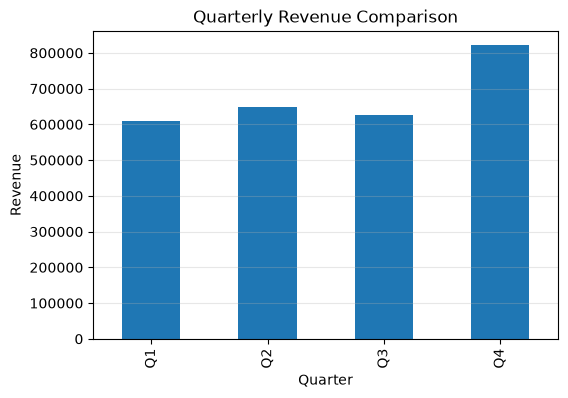

In [35]:
quarter_revenue.plot(
    kind="bar",
    x="Quarter",
    y="Revenue",
    figsize=(6,4),
    legend=False
)

plt.title("Quarterly Revenue Comparison")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 9.2 Quarterly Growth Rate

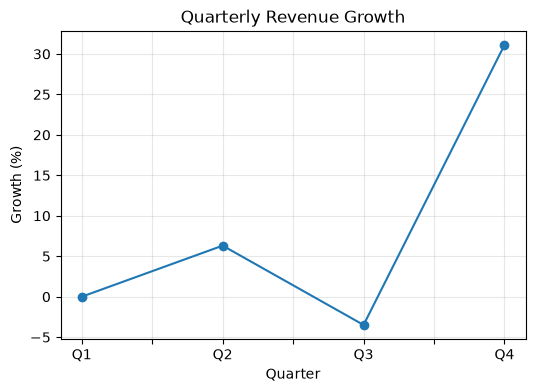

In [36]:
# Add Growth Percentage
quarter_revenue["Growth (%)"] = (
    quarter_revenue["Revenue"]
    .pct_change()
    .mul(100)
    .fillna(0)
    .round(2)
)

# Plot Quarterly Growth
quarter_revenue.plot(
    kind="line",
    x="Quarter",
    y="Growth (%)",
    marker="o",
    figsize=(6,4),
    legend=False
)

plt.title("Quarterly Revenue Growth")
plt.xlabel("Quarter")
plt.ylabel("Growth (%)")
plt.grid(alpha=0.3)

plt.show()

### 9.3 Monthly Revenue

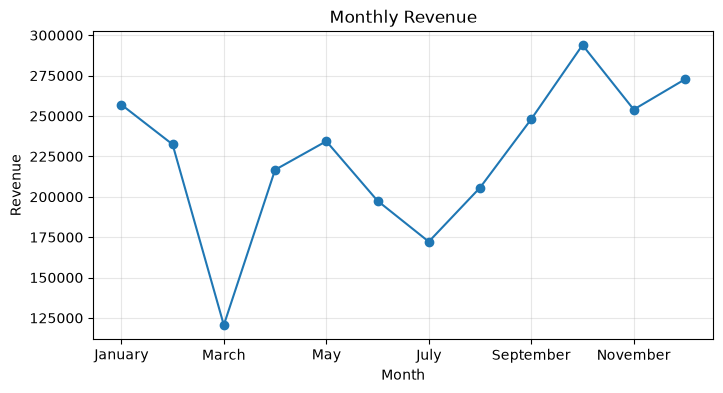

In [37]:
monthly_revenue.plot(
    kind="line",
    x="Month",
    y="Subtotal",
    marker="o",
    figsize=(8,4),
    legend=False
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)

plt.show()


### 9.4 Revenue by Weekday

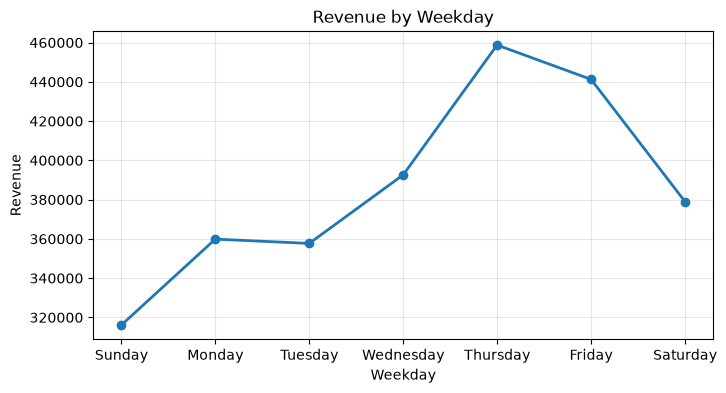

In [38]:
weekday_revenue.plot(
    kind="line",
    x="Weekday",
    y="Subtotal",
    marker="o",
    linewidth=2,
    figsize=(8,4),
    legend=False
)

plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)

plt.show()

### 9.5 Revenue by Hour

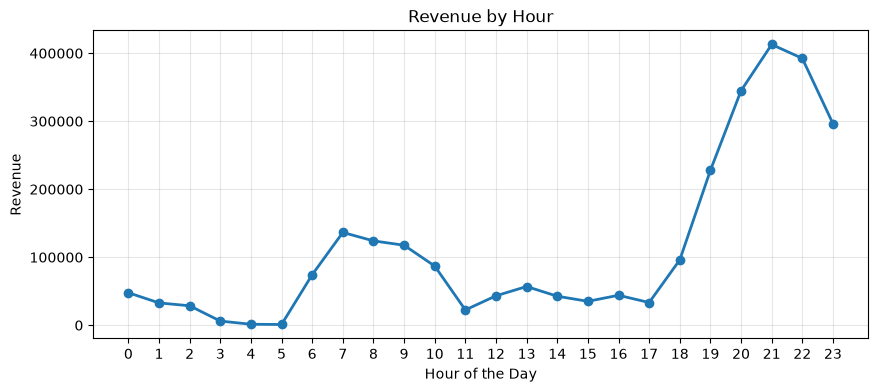

In [39]:
hourly_revenue.plot(
    kind="line",
    x="Hour",
    y="Subtotal",
    marker="o",
    linewidth=2,
    figsize=(10,4),
    legend=False
)

plt.title("Revenue by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Revenue")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()





### 9.6 Top 10 Products by Revenue

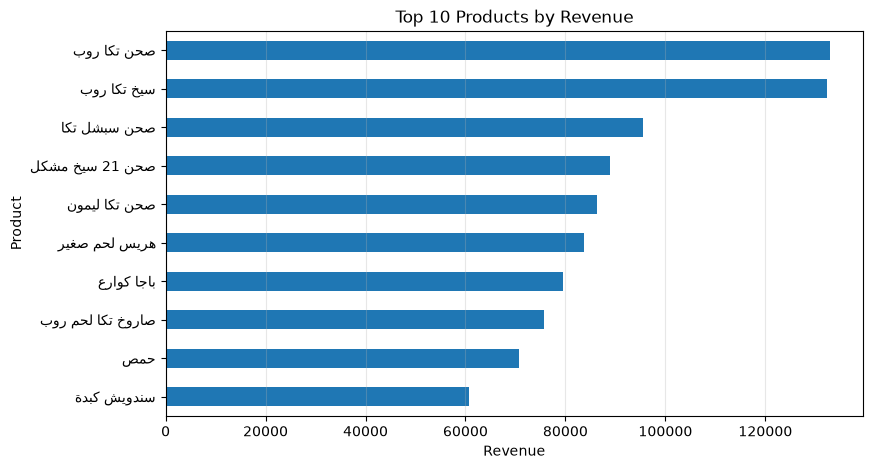

In [40]:
top10_revenue = (
    df1.groupby("Product", observed=False)["Subtotal"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

top10_revenue.plot(
    kind="barh",
    figsize=(9,5)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()  # Highest revenue at the top
plt.grid(axis="x", alpha=0.3)

plt.show()




### 9.7 Least Sold Products

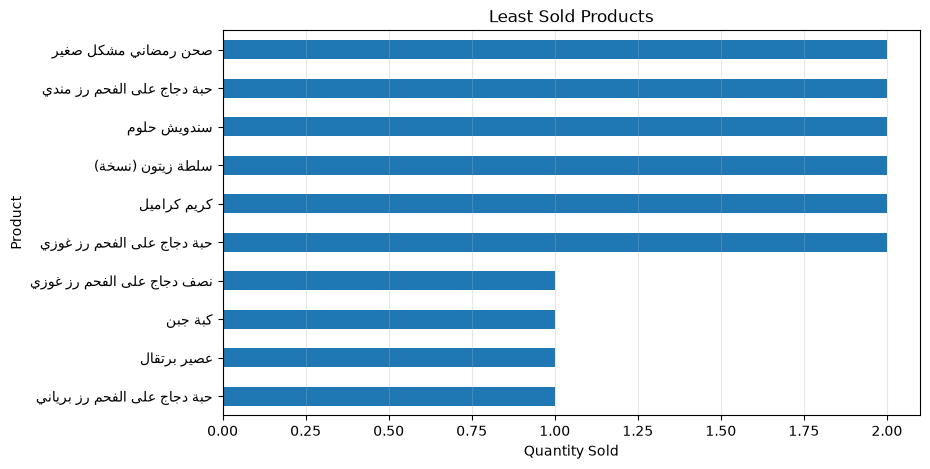

In [41]:
least_sold = (
    df1.groupby("Product", observed=False)["Quantity"]
       .sum()
       .sort_values()
       .head(10)
)

least_sold.plot(
    kind="barh",
    figsize=(9,5)
)

plt.title("Least Sold Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)

plt.show()

### 9.8 Most Refunded Products

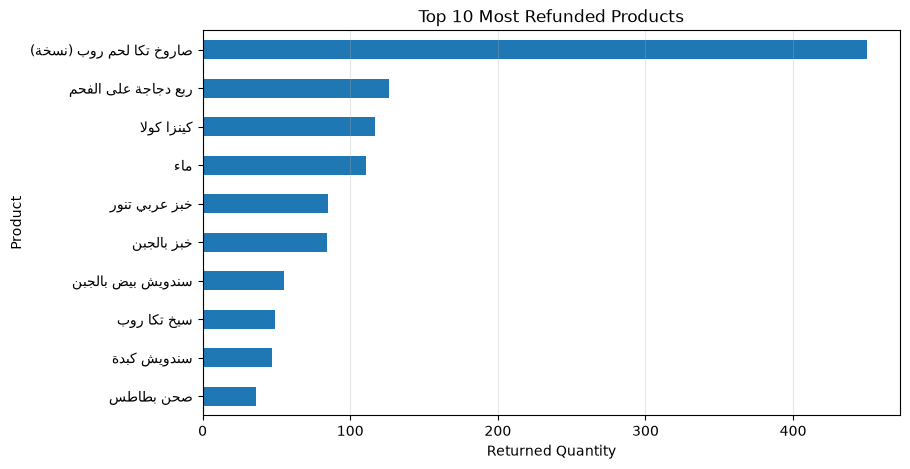

In [42]:
most_refunded = (
    df1[df1["Quantity"] < 0]
    .groupby("Product", observed=False)["Quantity"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

most_refunded.plot(
    kind="barh",
    figsize=(9,5)
)

plt.title("Top 10 Most Refunded Products")
plt.xlabel("Returned Quantity")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

### 9.9 Delivery Applications Revenue

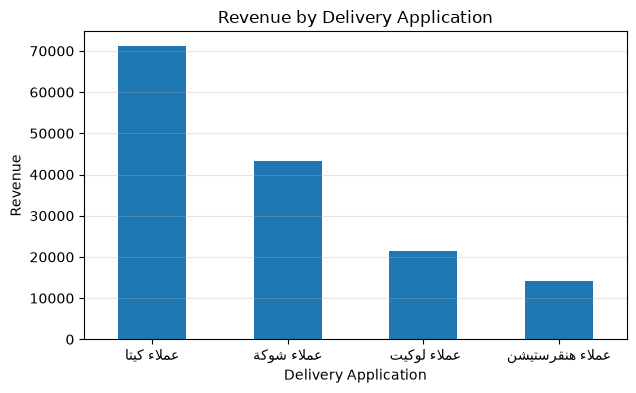

In [43]:
selected_apps = [
    "عملاء كيتا",
    "عملاء شوكة",
    "عملاء لوكيت ",
    "عملاء هنقرستيشن"
]

delivery_revenue = (
    df1[df1["Customer"].isin(selected_apps)]
    .groupby("Customer", observed=False)["Subtotal"]
    .sum()
    .reindex(selected_apps)
)

delivery_revenue.plot(
    kind="bar",
    figsize=(7,4),
    legend=False
)

plt.title("Revenue by Delivery Application")
plt.xlabel("Delivery Application")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()



### 9.10 Delivery Applications Revenue Share

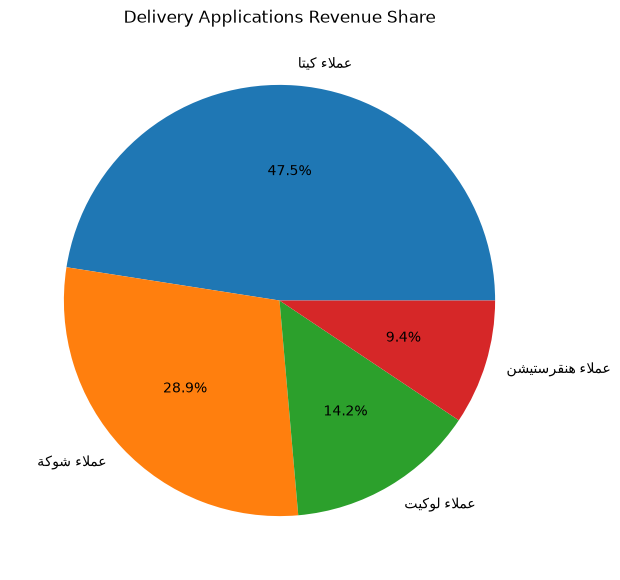

In [44]:
selected_apps = [
    "عملاء كيتا",
    "عملاء شوكة",
    "عملاء لوكيت ",
    "عملاء هنقرستيشن"
]

delivery_share = (
    df1[df1["Customer"].isin(selected_apps)]
    .groupby("Customer", observed=False)["Subtotal"]
    .sum()
    .reindex(selected_apps)
)

delivery_share.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7),
    ylabel=""
)

plt.title("Delivery Applications Revenue Share")

plt.show()

## 10. Key Insights


- The annual sales analysis showed that the business generated a total revenue of **2,705,203.98** SAR from **66,973 orders**, with **287,114** items sold during the year.

- Revenue increased from **610,056.57** in the first quarter to **820,653.80** in the fourth quarter. The fourth quarter recorded the highest performance, with a **31.11%** growth compared to the third quarter.

- **October** achieved the highest monthly revenue among all months, making it the strongest sales month of the year.

- Sales activity was highest on **Thursday**, which generated the greatest revenue compared to the other days of the week.

- The peak sales period occurred at **9:00 PM**, while the highest number of customer orders was recorded at **7:00 AM**.

- **صحن تكا روب** and **سيخ تكا روب** were the highest revenue-generating products throughout the year.

- **سيخ تكا روب** was also the most frequently sold product, followed by **ماء** and **خبز عربي تنور**, indicating consistent customer demand for these items.

- Several products recorded very low sales quantities, suggesting limited customer demand throughout the year.

- **صاروخ تكا لحم روب (نسخة)** recorded the highest number of returned items, making it the most refunded product in the dataset.

- Among all delivery applications, **كيتا** generated the highest revenue and processed the largest number of orders, followed by **شوكة**, **لوكيت**, and **هنقرستيشن**.